# Обучение моделей предсказания массы морских черепах


Цель проекта: разработать надёжную модель линейной регрессии, которая будет использовать габариты и другие данные от TurtleCV для предсказания массы черепах.

Задачи:

- Провести исследовательский анализ данных
- Провести предобработку данных
- Обучить модели
- Проверить работу моделей на валидационной выборке
- Проверить работу лучшей модели на тестовой выборке
- Оценить важность признаков
- Написать функцию для прогнозирования веса черепах
- Сделать вывод




## Постановка задачи машинного обучения

- В проекте необходимо решить задачу линейной регрессии
- Целевая переменная: `weight`
- Для оценки качества модели будут использоваться следующие метрики: `MSE`, `RMSE`, `MAE`, `MAPE`, `R2`.
- Проект можно считать успешным при условии, что `MAE` < 5 и `R2` > 0,97

## Подключение и настройка библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso, LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score, mean_absolute_error
from sklearn.dummy import DummyRegressor

## Загрузка датасета

Выгрузим данные



In [2]:
df = pd.read_csv('C:/Users/OC/Downloads/datasets/turtles.csv', sep='\t', decimal=',')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   object 
 2   registration number  8832 non-null   object 
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count         8861 non-null   i

Загрузка прошла успешно. В датасете 8861 строк и 19 столбцов, в большинстве столбцов тип данных `float(10)` или `int(8)`. Пропуски пристутствуют в 12 столбцах, в дальнейшем их будет необходимо обработать.

## Исследовательский анализ данных

Выясним, о каких видах черепах представлены данные

In [3]:
uniq_name = df['binomial_name'].unique()
uniq_name

array(['Caretta caretta', 'Lepidochelys olivacea',
       'LEPIDOCHELYS OLIVACEA', 'Lepidochelys Olivacea',
       'lepidochelys olivacea', 'Chelonia mydas',
       'ERETMOCHELYS IMBRICATA', 'Eretmochelys imbricata',
       'Dermochelys coriacea', 'caretta caretta', 'CARETTA CARETTA',
       'chelonia mydas', 'Chelonia Mydas', 'CHELONIA MYDAS',
       'Dermochelys Coriacea', 'eretmochelys imbricata', nan,
       'Caretta Caretta', 'lepidochelys kempii', 'Lepidochelys kempii',
       'Eretmochelys Imbricata', 'dermochelys coriacea',
       'Lepidochelys Kempii', 'DERMOCHELYS CORIACEA'], dtype=object)

Можно заметить, что названия видов повторяются, поэтому для точной оценки приведем все названия к нижнему регистру


In [4]:
df['binomial_name'] = df['binomial_name'].str.lower()

In [5]:
uniq_name = df['binomial_name'].unique()
uniq_name

array(['caretta caretta', 'lepidochelys olivacea', 'chelonia mydas',
       'eretmochelys imbricata', 'dermochelys coriacea', nan,
       'lepidochelys kempii'], dtype=object)

Теперь можно увидеть, что всего в датасете представленны данные о 6 видах черепах, и также присутствует пустое значение.
Посмортим распределение данных о черепахах по видам.

In [6]:
count_name = df.groupby('binomial_name')['id'].count().sort_values(ascending=False)
count_name

binomial_name
lepidochelys olivacea     4215
chelonia mydas            2829
caretta caretta            847
dermochelys coriacea       484
eretmochelys imbricata     409
lepidochelys kempii         28
Name: id, dtype: int64

Больше всего данных о виде `lepidochelys olivacea`. Но нам для работы нужен только вид `chelonia mydas`. Поэтому отфильтруем датасет с учетом этого требования

In [7]:
df_new = df[(df['binomial_name'] == 'chelonia mydas')]
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2829 entries, 8 to 8859
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   2829 non-null   int64  
 1   binomial_name        2829 non-null   object 
 2   registration number  2825 non-null   object 
 3   shell_length         2794 non-null   float64
 4   shell_width          2829 non-null   int64  
 5   head_length          2790 non-null   float64
 6   head_width           2790 non-null   float64
 7   flipper_length_1     2829 non-null   int64  
 8   flipper_width_1      2829 non-null   int64  
 9   flipper_length_2     2829 non-null   int64  
 10  flipper_width_2      2829 non-null   int64  
 11  flipper_length_3     2798 non-null   float64
 12  flipper_width_3      2798 non-null   float64
 13  flipper_length_4     2798 non-null   float64
 14  flipper_width_4      2798 non-null   float64
 15  circle_count         2829 non-null   int64 

Датасет отфильтрован, теперь проверим, все ли признаки нам необходимы. Нам точно ненужны столбцы `id`, `binomial_name`, `registration number`, их мы удалим. На первый взгляд признаки `measure_count`, `shell_crack` и `timestamp` кажутся бесполезными, но проверим корреляцию веса с другими показателями с помощью матрицы корреляции.


In [8]:
df_new.drop(['id', 'binomial_name', 'registration number'], axis=1, inplace=True)
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2829 entries, 8 to 8859
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shell_length      2794 non-null   float64
 1   shell_width       2829 non-null   int64  
 2   head_length       2790 non-null   float64
 3   head_width        2790 non-null   float64
 4   flipper_length_1  2829 non-null   int64  
 5   flipper_width_1   2829 non-null   int64  
 6   flipper_length_2  2829 non-null   int64  
 7   flipper_width_2   2829 non-null   int64  
 8   flipper_length_3  2798 non-null   float64
 9   flipper_width_3   2798 non-null   float64
 10  flipper_length_4  2798 non-null   float64
 11  flipper_width_4   2798 non-null   float64
 12  circle_count      2829 non-null   int64  
 13  measure_count     2748 non-null   float64
 14  shell_crack       677 non-null    float64
 15  timestamp         2829 non-null   int64  
 16  weight            2826 non-null   float64
dtype

C:\Users\OC\AppData\Local\Temp\ipykernel_60824\1207004915.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new.drop(['id', 'binomial_name', 'registration number'], axis=1, inplace=True)


In [9]:
corr = df_new.corr()['weight']
corr

shell_length        0.370473
shell_width         0.374233
head_length         0.872647
head_width          0.866361
flipper_length_1    0.922187
flipper_width_1     0.894322
flipper_length_2    0.920269
flipper_width_2     0.899160
flipper_length_3    0.917780
flipper_width_3     0.897167
flipper_length_4    0.921627
flipper_width_4     0.897222
circle_count        0.505133
measure_count      -0.039915
shell_crack         0.514051
timestamp           0.038815
weight              1.000000
Name: weight, dtype: float64

Можно заметить, что у веса наименьшая корреляция с `measure_count` и `timestamp`, поэтому удалим их

In [10]:
df_new.drop('measure_count', axis=1, inplace=True)
df_new.drop('timestamp', axis=1, inplace=True)
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2829 entries, 8 to 8859
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shell_length      2794 non-null   float64
 1   shell_width       2829 non-null   int64  
 2   head_length       2790 non-null   float64
 3   head_width        2790 non-null   float64
 4   flipper_length_1  2829 non-null   int64  
 5   flipper_width_1   2829 non-null   int64  
 6   flipper_length_2  2829 non-null   int64  
 7   flipper_width_2   2829 non-null   int64  
 8   flipper_length_3  2798 non-null   float64
 9   flipper_width_3   2798 non-null   float64
 10  flipper_length_4  2798 non-null   float64
 11  flipper_width_4   2798 non-null   float64
 12  circle_count      2829 non-null   int64  
 13  shell_crack       677 non-null    float64
 14  weight            2826 non-null   float64
dtypes: float64(9), int64(6)
memory usage: 353.6 KB


C:\Users\OC\AppData\Local\Temp\ipykernel_60824\4294708523.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new.drop('measure_count', axis=1, inplace=True)
C:\Users\OC\AppData\Local\Temp\ipykernel_60824\4294708523.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new.drop('timestamp', axis=1, inplace=True)


Признаки удалены, но можно заметить, что в столбцах `shell_length`, `head_length`, `head_width`, `flipper_length_3`, `flipper_width_3`, `flipper_length_4`, `flipper_width_4`, `shell_crack`, `weight` присутствуют пропуски. Проверим их количество в относительных значениях



In [11]:
is_null = df_new.isna().sum()/len(df_new)
is_null.sort_values(ascending=False)

shell_crack         0.760693
head_length         0.013786
head_width          0.013786
shell_length        0.012372
flipper_length_3    0.010958
flipper_width_3     0.010958
flipper_length_4    0.010958
flipper_width_4     0.010958
weight              0.001060
shell_width         0.000000
flipper_length_1    0.000000
flipper_width_1     0.000000
flipper_length_2    0.000000
flipper_width_2     0.000000
circle_count        0.000000
dtype: float64

Больше всего пропусков в `shell_crack`, это связано с тем, что у многих черепах может не быть трещин на панцире, поэтому эти пропуски можно оставить или заменить на 0. Так же стоит отметить пропуски в `weight`, так как процент пропусков очень мал, строки с пропусками можно удалить. Остальные столбцы с пропусками оставим до разделения.

In [12]:
df_new['shell_crack'] = df_new['shell_crack'].fillna(0)

C:\Users\OC\AppData\Local\Temp\ipykernel_60824\2145639518.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['shell_crack'] = df_new['shell_crack'].fillna(0)


In [13]:
df_new = df_new.dropna(subset=['weight'])
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2826 entries, 8 to 8859
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shell_length      2791 non-null   float64
 1   shell_width       2826 non-null   int64  
 2   head_length       2787 non-null   float64
 3   head_width        2787 non-null   float64
 4   flipper_length_1  2826 non-null   int64  
 5   flipper_width_1   2826 non-null   int64  
 6   flipper_length_2  2826 non-null   int64  
 7   flipper_width_2   2826 non-null   int64  
 8   flipper_length_3  2795 non-null   float64
 9   flipper_width_3   2795 non-null   float64
 10  flipper_length_4  2795 non-null   float64
 11  flipper_width_4   2795 non-null   float64
 12  circle_count      2826 non-null   int64  
 13  shell_crack       2826 non-null   float64
 14  weight            2826 non-null   float64
dtypes: float64(9), int64(6)
memory usage: 353.2 KB


Определим, есть ли в данных явные дубликаты


In [14]:
dup = df_new[df_new.duplicated()]
dup

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,shell_crack,weight
7842,NaN,849,184.0,144.0,628,547,529,461,457.0,399.0,416.0,460.0,85,0.0,81.789
7844,792.0,690,144.0,139.0,455,499,499,510,368.0,335.0,377.0,380.0,80,0.0,63.676
7845,867.0,809,177.0,158.0,533,488,555,435,455.0,312.0,469.0,365.0,68,0.0,70.837
7847,854.0,714,152.0,165.0,535,462,420,457,379.0,356.0,378.0,394.0,78,0.0,68.990
7851,814.0,776,152.0,139.0,520,470,492,454,387.0,394.0,446.0,359.0,89,0.0,71.541
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8844,734.0,747,101.0,141.0,484,410,469,276,372.0,298.0,445.0,308.0,60,0.0,57.859
8845,844.0,760,125.0,177.0,567,476,492,448,373.0,351.0,396.0,408.0,83,1.0,69.706
8850,823.0,723,148.0,165.0,495,434,424,467,422.0,390.0,394.0,376.0,55,0.0,67.719
8856,1241.0,1010,210.0,272.0,597,640,724,618,598.0,475.0,504.0,492.0,115,5.0,121.688


В датасете есть явные дубликаты, удалим их

In [15]:
df_new = df_new.drop_duplicates()
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2486 entries, 8 to 7840
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shell_length      2457 non-null   float64
 1   shell_width       2486 non-null   int64  
 2   head_length       2451 non-null   float64
 3   head_width        2451 non-null   float64
 4   flipper_length_1  2486 non-null   int64  
 5   flipper_width_1   2486 non-null   int64  
 6   flipper_length_2  2486 non-null   int64  
 7   flipper_width_2   2486 non-null   int64  
 8   flipper_length_3  2457 non-null   float64
 9   flipper_width_3   2457 non-null   float64
 10  flipper_length_4  2457 non-null   float64
 11  flipper_width_4   2457 non-null   float64
 12  circle_count      2486 non-null   int64  
 13  shell_crack       2486 non-null   float64
 14  weight            2486 non-null   float64
dtypes: float64(9), int64(6)
memory usage: 310.8 KB


Проверим распределение данных

In [16]:
shell_length_des = df_new['shell_length'].describe()
shell_length_des

count     2457.000000
mean      1047.963777
std        568.694898
min        645.000000
25%        837.000000
50%        980.000000
75%       1172.000000
max      12840.000000
Name: shell_length, dtype: float64

In [17]:
shell_length_des = df_new['shell_width'].describe()
shell_length_des

count     2486.000000
mean       945.018101
std        507.521189
min        564.000000
25%        752.250000
50%        889.000000
75%       1056.000000
max      11550.000000
Name: shell_width, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

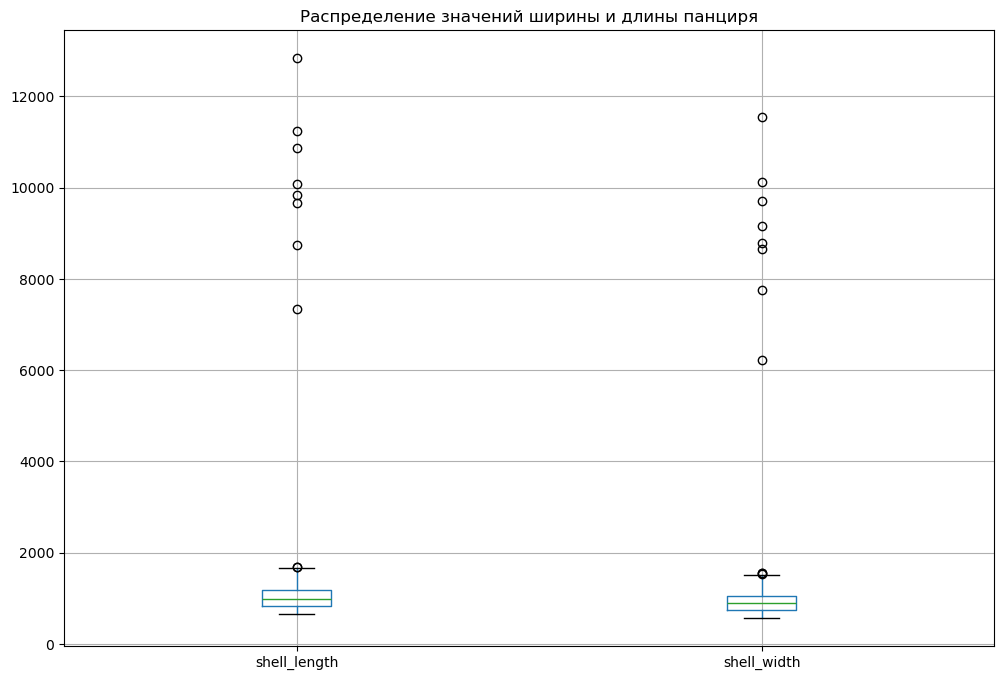

In [18]:
plt.figure(figsize=(12,8))
df_new.boxplot(['shell_length', 'shell_width'])
plt.title('Распределение значений ширины и длины панциря')
plt.show

Значения длины и ширины панциря распределены неравномерно. Из задания мы знаем, что некторые данные дополнительно умножены на 10. Масимальная длина панциря данного вида черепах достигает 200 см или 2000 мм, ширина тоже больше быть не может, значит, чтобы выровнять значения, разделим на 10 все значения, которые больше 2000

In [19]:
df_new.loc[df_new['shell_length'] > 2000, 'shell_length'] /= 10
df_new['shell_length'].describe()

count    2457.000000
mean     1018.436304
std       222.149470
min       645.000000
25%       837.000000
50%       979.000000
75%      1168.000000
max      1683.000000
Name: shell_length, dtype: float64

In [20]:
df_new.loc[df_new['shell_width'] > 2000, 'shell_width'] /= 10
df_new['shell_width'].describe()

count    2486.000000
mean      918.970233
std       203.241558
min       564.000000
25%       752.000000
50%       887.000000
75%      1054.000000
max      1554.000000
Name: shell_width, dtype: float64

Значения стали ровнее, теперь проверим распределение значений длины и ширины головы

In [21]:
df_new['head_length'].describe()

count    2451.000000
mean      169.723378
std        41.335454
min        87.000000
25%       138.000000
50%       163.000000
75%       195.000000
max       328.000000
Name: head_length, dtype: float64

In [22]:
df_new['head_width'].describe()

count    2451.000000
mean      183.321093
std        45.477540
min        96.000000
25%       148.000000
50%       176.000000
75%       212.000000
max       382.000000
Name: head_width, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

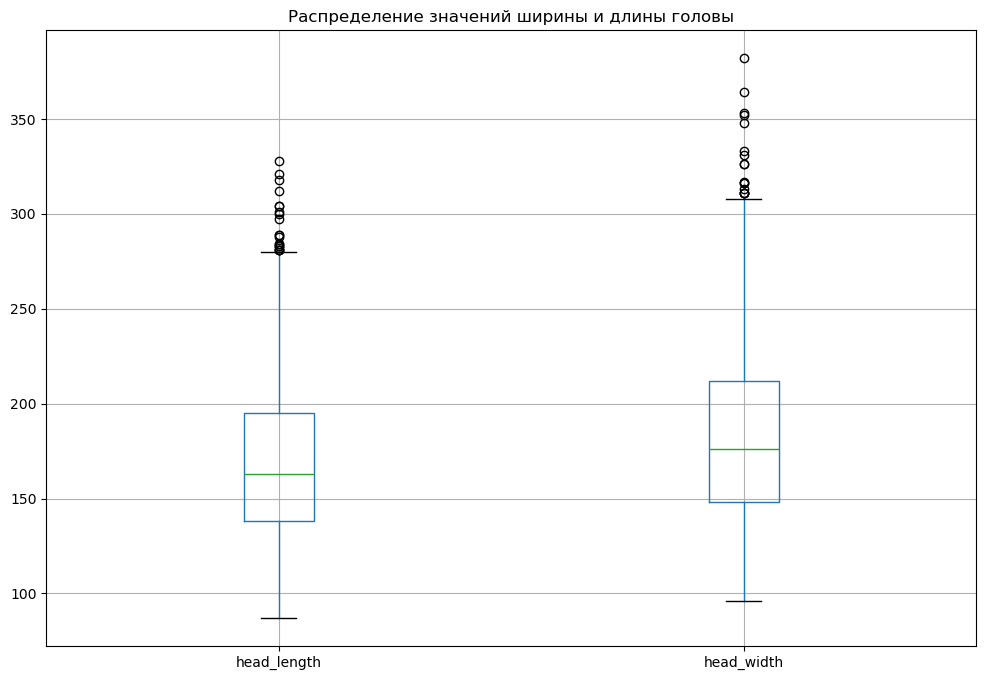

In [23]:
plt.figure(figsize=(12,8))
df_new.boxplot(['head_length', 'head_width'])
plt.title('Распределение значений ширины и длины головы')
plt.show

In [24]:
df_new[(df_new['head_length'] > 300)]

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,shell_crack,weight
629,1473.0,1314,312.0,279.0,926,963,891,855,794.0,777.0,691.0,661.0,77,0.0,189.012
2141,1546.0,1314,318.0,291.0,970,808,1019,877,683.0,636.0,845.0,541.0,95,0.0,197.047
3595,1483.0,1363,304.0,245.0,1058,916,862,909,678.0,726.0,666.0,714.0,99,0.0,183.804
7157,1471.0,1280,304.0,278.0,934,829,949,850,652.0,521.0,728.0,614.0,69,0.0,169.114
7232,1527.0,1337,321.0,317.0,935,765,1009,808,779.0,544.0,702.0,675.0,130,0.0,184.488
7362,1658.0,1373,328.0,267.0,1011,941,954,868,746.0,712.0,694.0,748.0,115,0.0,189.607
7786,1550.0,1355,301.0,352.0,961,855,956,925,697.0,771.0,820.0,649.0,114,0.0,186.008


Можно заметить, что выбросы в данных есть. Но если проанализировать максимальные значения длины и ширины головы черепахи, то относительно длины тела (около 150 см) данные значения приемлемы (около 30 см, что примерно 1/5 от тела). Поэтому оставим эти значения без изменения. Посмотрим распределение значений по ластам черепах

Проверим распределение данных о ластах

In [25]:
df_new['flipper_length_1'].describe()

count    2486.000000
mean      612.010459
std       142.589526
min       339.000000
25%       502.000000
50%       587.000000
75%       702.000000
max      1147.000000
Name: flipper_length_1, dtype: float64

In [26]:
df_new['flipper_width_1'].describe()

count    2486.000000
mean      549.364441
std       131.859104
min       245.000000
25%       449.000000
50%       527.000000
75%       632.000000
max      1072.000000
Name: flipper_width_1, dtype: float64

Проанализируем данные о ластах на примере одной, так как на диагрмамме видно, что они примерно одинаково распределены



<function matplotlib.pyplot.show(close=None, block=None)>

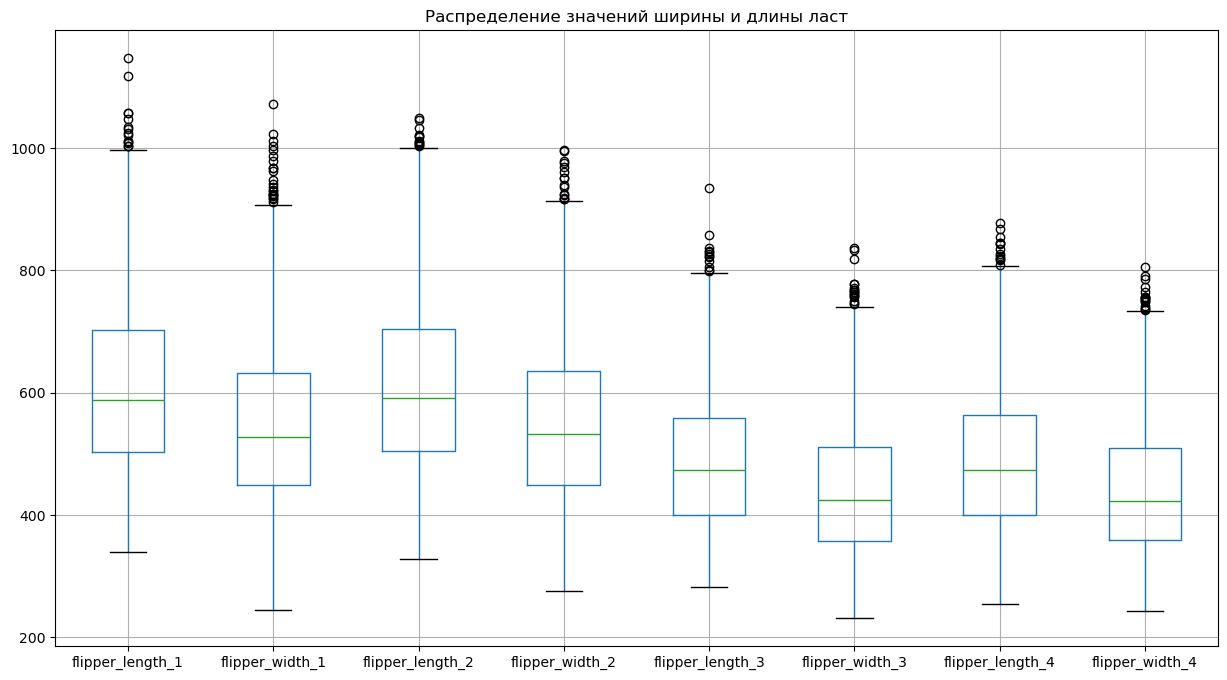

In [27]:
plt.figure(figsize=(15,8))
df_new.boxplot(['flipper_length_1', 'flipper_width_1', 'flipper_length_2', 'flipper_width_2', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4'])
plt.title('Распределение значений ширины и длины ласт')
plt.show

In [28]:
df_new[(df_new['flipper_length_1'] > 800)]

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,shell_crack,weight
11,1336.0,1318,207.0,248.0,845,704,661,768,587.0,686.0,661.0,585.0,111,5.0,154.074
84,1288.0,1242,171.0,198.0,920,657,785,818,648.0,675.0,595.0,600.0,116,5.0,152.416
116,1381.0,1385,196.0,259.0,875,654,896,730,613.0,659.0,719.0,448.0,87,0.0,152.788
165,1284.0,1155,231.0,203.0,814,563,801,603,653.0,555.0,593.0,588.0,89,0.0,127.917
186,1470.0,1327,208.0,262.0,859,839,935,749,687.0,503.0,693.0,708.0,71,0.0,163.498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7766,1262.0,1082,232.0,219.0,890,689,855,712,556.0,540.0,650.0,575.0,109,0.0,141.916
7786,1550.0,1355,301.0,352.0,961,855,956,925,697.0,771.0,820.0,649.0,114,0.0,186.008
7791,1268.0,1194,213.0,170.0,862,722,823,647,634.0,529.0,607.0,540.0,83,0.0,134.726
7804,1381.0,1305,284.0,256.0,908,789,832,749,634.0,511.0,683.0,568.0,74,0.0,164.178


Можно заметить, что выбросы в данных есть. Но если проанализировать максимальные значения длины и ширины лвст черепахи, то относительно длины тела (около 150 см) данные значения приемлемы (около 80 см). Поэтому оставим эти значения без изменения. Посмотрим распределение значений по количеству колец роста

In [29]:
df_new['circle_count'].describe()

count    2486.000000
mean       80.931617
std        16.228851
min        29.000000
25%        70.000000
50%        80.000000
75%        91.000000
max       143.000000
Name: circle_count, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

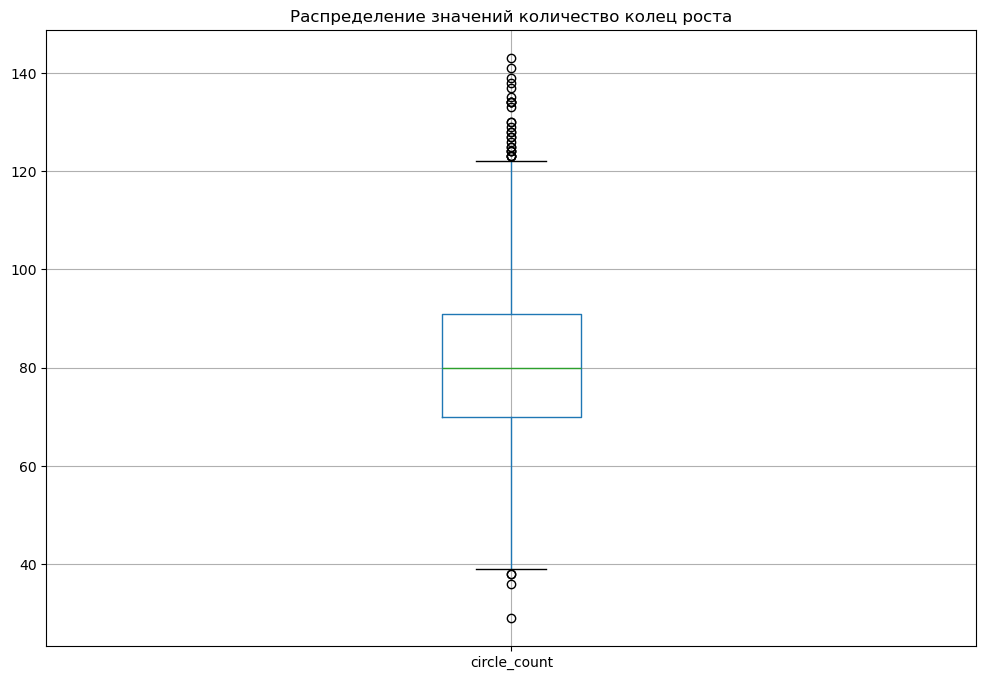

In [30]:
plt.figure(figsize=(12,8))
df_new.boxplot('circle_count')
plt.title('Распределение значений количество колец роста')
plt.show

Черепахи данного вида могут доживать до 70 лет, по кольцам можно определить примерный возраст черепахи, разделив их количество на 2. Максимальное значение 143 кольца, значит черепахе около 70 лет, что нормально. 

Проверим распределение значений трещин панциря

In [31]:
df_new['shell_crack'].describe()

count    2486.000000
mean        0.419549
std         0.960259
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         5.000000
Name: shell_crack, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

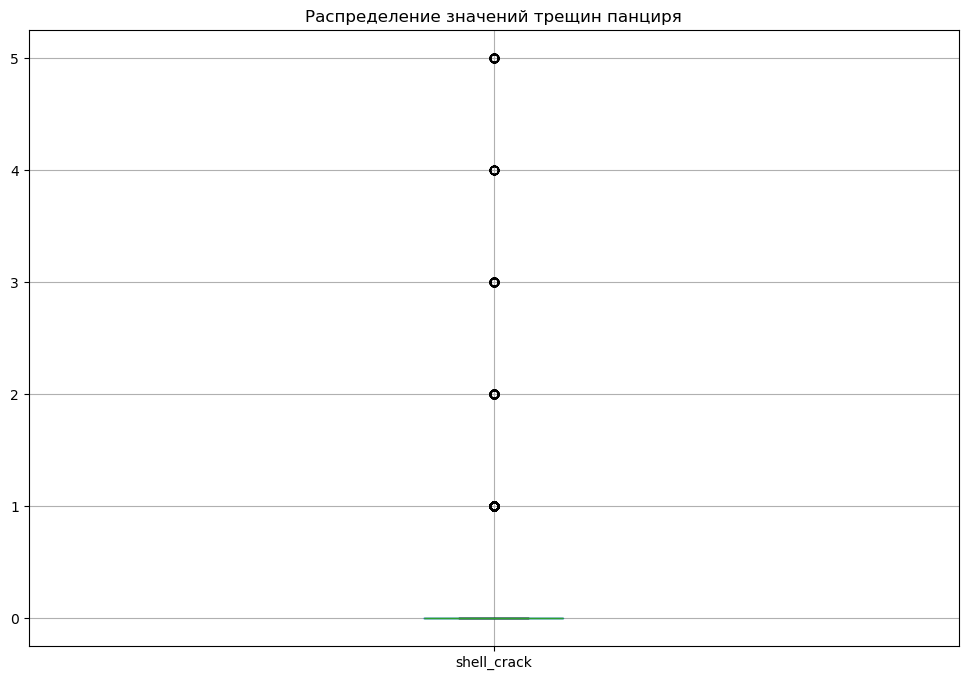

In [32]:
plt.figure(figsize=(12,8))
df_new.boxplot('shell_crack')
plt.title('Распределение значений трещин панциря')
plt.show

Распределение значений нормальное. Проверим распределение веса черепах


In [33]:
df_new['weight'].describe()

count    2486.000000
mean       96.068853
std        35.149431
min         0.000000
25%        67.500750
50%        87.900000
75%       117.629500
max       199.961000
Name: weight, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

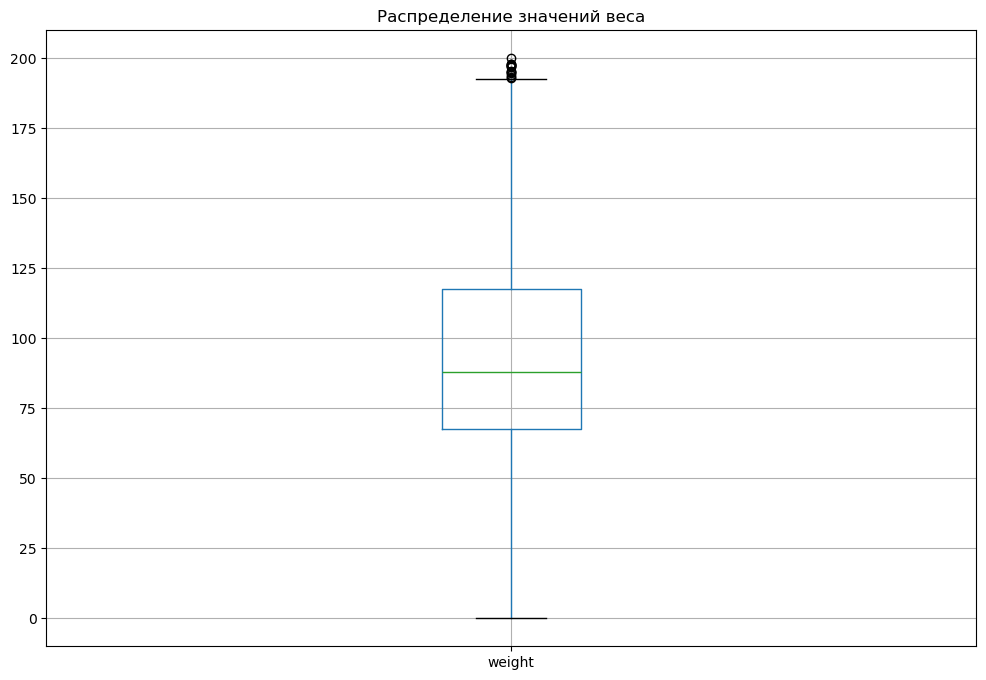

In [34]:
plt.figure(figsize=(12,8))
df_new.boxplot('weight')
plt.title('Распределение значений веса')
plt.show

In [35]:
df_new[(df_new['weight'] == 0)]

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,shell_crack,weight
809,1506.0,1341,262.0,265.0,979,777,910,732,728.0,651.0,604.0,676.0,109,0.0,0.0
3185,780.0,797,145.0,150.0,539,426,536,513,399.0,388.0,361.0,369.0,70,0.0,0.0
5004,892.0,826,124.0,158.0,543,482,517,528,431.0,442.0,448.0,377.0,83,0.0,0.0


Максимальное значение веса вполне приемлемо, черепахи данного вида могут достигать 200 кг, но наличие нулевых значений ненормально, так как черепаха не может весить 0 кг, удалим строки с нулевыми значениями и проверим распределение заново

In [36]:
df_new = df_new[df_new['weight'] > 0]

In [37]:
df_new['weight'].describe()

count    2483.000000
mean       96.184925
std        35.011526
min        49.045000
25%        67.538000
50%        87.951000
75%       117.638500
max       199.961000
Name: weight, dtype: float64

In [38]:
df_new['flipper_length_2'].describe()

count    2483.000000
mean      611.838905
std       138.925759
min       327.000000
25%       504.500000
50%       591.000000
75%       704.000000
max      1049.000000
Name: flipper_length_2, dtype: float64

Можно заметить, что признаки, представленные в датасете разные по масштабу. Особенно сильно различается масштаб количество колец роста и вес с длиной и шириной панциря. Для решения данной проблемы, чтобы можно было корректно обучить модель, после разделения данных на выборки, признаки надо масштабировать


После обработки данных еще раз проверим корреляцию признаков

In [39]:
corr_2 = df_new.corr()['weight']
corr_2

shell_length        0.984461
shell_width         0.968626
head_length         0.875362
head_width          0.868456
flipper_length_1    0.927451
flipper_width_1     0.897135
flipper_length_2    0.923784
flipper_width_2     0.903030
flipper_length_3    0.922198
flipper_width_3     0.901860
flipper_length_4    0.923569
flipper_width_4     0.902358
circle_count        0.510257
shell_crack         0.171192
weight              1.000000
Name: weight, dtype: float64

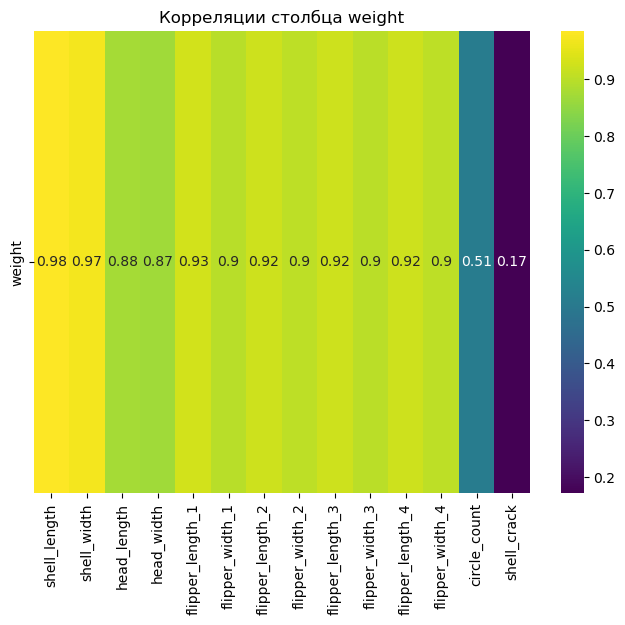

In [40]:
corr_3 = df_new.corr()
corr_weight = corr_3.loc[['weight'], corr_3.columns != 'weight']
plt.figure(figsize=(8,6))
sns.heatmap(corr_weight, annot=True, cmap='viridis') 
plt.title('Корреляции столбца weight') 
plt.show()

Можно заметить, что целевая переменная сильно коррелирует со всеми признаками. Проврерим корреляцию признаков между собой, чтобы выявить наличие мультиколлинеарности.


In [41]:
corr_4 = df_new.corr()
corr_4

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,shell_crack,weight
shell_length,1.000000,0.959955,0.867124,0.860427,0.920007,0.890818,0.917217,0.897907,0.915463,0.895125,0.919118,0.895308,0.500605,0.169770,0.984461
shell_width,0.959955,1.000000,0.851398,0.843446,0.904139,0.876169,0.905369,0.884712,0.901721,0.880621,0.902835,0.884019,0.495655,0.168397,0.968626
head_length,0.867124,0.851398,1.000000,0.763530,0.813087,0.788752,0.815008,0.796350,0.810695,0.792826,0.810176,0.803061,0.452650,0.133660,0.875362
head_width,0.860427,0.843446,0.763530,1.000000,0.808789,0.780595,0.806570,0.791034,0.801909,0.786405,0.816958,0.795211,0.445499,0.139297,0.868456
flipper_length_1,0.920007,0.904139,0.813087,0.808789,1.000000,0.836467,0.869192,0.850201,0.856647,0.841457,0.864910,0.838900,0.474170,0.163663,0.927451
flipper_width_1,0.890818,0.876169,0.788752,0.780595,0.836467,1.000000,0.833617,0.818607,0.834872,0.817634,0.835482,0.814079,0.477996,0.160720,0.897135
flipper_length_2,0.917217,0.905369,0.815008,0.806570,0.869192,0.833617,1.000000,0.842213,0.858202,0.841392,0.856975,0.841569,0.470078,0.167273,0.923784
flipper_width_2,0.897907,0.884712,0.796350,0.791034,0.850201,0.818607,0.842213,1.000000,0.841124,0.824919,0.847327,0.818643,0.462638,0.171439,0.903030
flipper_length_3,0.915463,0.901721,0.810695,0.801909,0.856647,0.834872,0.858202,0.841124,1.000000,0.842082,0.865100,0.841038,0.465957,0.162329,0.922198
flipper_width_3,0.895125,0.880621,0.792826,0.786405,0.841457,0.817634,0.841392,0.824919,0.842082,1.000000,0.846154,0.822725,0.457159,0.154358,0.901860


Можно заметить, что большинство признаков коррелируеют, что может привести к проблемам с обучением моделей. Для решения данной проблемы стоит использовать регуляризацию при обучении моделей.


## Предобработка данных

Сначала разделим датасет на признаки и целевую переменную

In [42]:
X = df_new.drop('weight', axis=1)
y = df_new['weight']

Проведем разделение данных на выборки

In [43]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size = 0.2, shuffle=True, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size = 0.25, shuffle=True, random_state=42)
X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape

((1489, 14), (497, 14), (497, 14), (1489,), (497,), (497,))

Заполним средними медианнными значениями пропуски в столбцах `shell_length`, `head_length`, `head_width`, `flipper_length_3`, `flipper_width_3`, `flipper_length_4`, `flipper_width_4`

In [44]:
median_value = X_train[['shell_length', 'head_length', 'head_width', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4']].median()
X_train[['shell_length', 'head_length', 'head_width', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4']] = X_train[['shell_length', 'head_length', 'head_width', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4']].fillna(median_value)
X_val[['shell_length', 'head_length', 'head_width', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4']] = X_val[['shell_length', 'head_length', 'head_width', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4']].fillna(median_value)
X_test[['shell_length', 'head_length', 'head_width', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4']] = X_test[['shell_length', 'head_length', 'head_width', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4']].fillna(median_value)
X_val.info()

<class 'pandas.core.frame.DataFrame'>
Index: 497 entries, 5195 to 7346
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shell_length      497 non-null    float64
 1   shell_width       497 non-null    int64  
 2   head_length       497 non-null    float64
 3   head_width        497 non-null    float64
 4   flipper_length_1  497 non-null    int64  
 5   flipper_width_1   497 non-null    int64  
 6   flipper_length_2  497 non-null    int64  
 7   flipper_width_2   497 non-null    int64  
 8   flipper_length_3  497 non-null    float64
 9   flipper_width_3   497 non-null    float64
 10  flipper_length_4  497 non-null    float64
 11  flipper_width_4   497 non-null    float64
 12  circle_count      497 non-null    int64  
 13  shell_crack       497 non-null    float64
dtypes: float64(8), int64(6)
memory usage: 58.2 KB


Пропуски обработаны. Напишем функцию для стандартизации и нормализации

In [45]:
def scale_data(X_train, X_val, X_test, method='standard'):
    if method == 'standard':
        mean = X_train.mean()
        std = X_train.std()
        X_train_scaled = (X_train - mean) / std
        X_val_scaled = (X_val - mean) / std
        X_test_scaled = (X_test - mean) / std
    elif method == 'minmax':
        min_val = X_train.min()
        max_val = X_train.max()
        X_train_scaled = (X_train - min_val) / (max_val - min_val)
        X_val_scaled = (X_val - min_val) / (max_val - min_val)
        X_test_scaled = (X_test - min_val) / (max_val - min_val)
    else:
        raise ValueError("Неверный метод масштабирования. Используйте 'standard' или 'minmax'.")
    return X_train_scaled, X_val_scaled, X_test_scaled

Стандартизируем данные



In [46]:
X_train_stand, X_val_stand, X_test_stand = scale_data(X_train, X_val, X_test, method='standard')
X_train_stand

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,shell_crack
480,1.127389,1.380710,-0.116294,1.481027,0.847984,1.363669,0.891581,0.872362,1.445725,1.943998,1.167716,0.926908,2.935430,-0.453158
2250,-0.033773,0.221485,0.153619,0.490339,0.108729,0.082258,-0.037717,-0.158573,0.363430,-0.200853,0.005927,0.409227,-0.486689,-0.453158
3837,0.224767,-0.094218,-0.042681,0.940652,0.460413,-0.218796,0.042774,0.360770,0.482666,-0.418172,0.546294,0.265427,1.193260,-0.453158
2000,-1.326473,-1.105456,-1.048720,-1.558584,-1.197529,-1.245468,-1.208486,-1.685597,-1.159120,-1.051234,-1.543123,-1.297202,-0.735571,-0.453158
4195,2.383802,0.685175,1.159659,1.571090,2.226014,2.019813,0.789139,2.709441,1.766744,1.367629,1.699076,2.336149,3.308752,-0.453158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5653,0.310947,0.453330,0.644370,-0.748021,-0.350615,0.429629,0.730600,-0.019048,0.601902,0.498350,0.348160,0.044933,-0.860011,-0.453158
3545,-0.809393,-0.705894,0.153619,-0.140099,-0.422387,-0.265112,-0.557246,-0.011297,-0.251093,-0.021328,-0.777604,-0.760348,-1.295554,-0.453158
5011,-0.877430,-0.434586,-0.337132,-0.545381,-0.759717,-0.380902,-0.345044,-0.507385,-0.856444,-0.758325,-1.281946,-0.597374,0.197735,-0.453158
7660,-1.208542,-1.100523,-1.514934,-1.648647,-0.357792,-1.893893,-0.923111,-0.755430,-1.287528,-0.852812,-1.164867,-0.875388,-2.291080,0.626445


Нормализируем данные

In [47]:
X_train_norm, X_val_norm, X_test_norm = scale_data(X_train, X_val, X_test, method='minmax')
X_train_norm

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,shell_crack
480,0.592486,0.637285,0.333333,0.603175,0.470440,0.611825,0.552068,0.523272,0.626087,0.681518,0.578352,0.535649,0.859813,0.0
2250,0.345857,0.399189,0.380952,0.428571,0.340881,0.398458,0.370899,0.335684,0.420870,0.306931,0.369952,0.436929,0.345794,0.0
3837,0.400771,0.334347,0.346320,0.507937,0.402516,0.348329,0.386591,0.430183,0.443478,0.268977,0.466882,0.409506,0.598131,0.0
2000,0.071291,0.126646,0.168831,0.067460,0.111950,0.177378,0.142653,0.057828,0.132174,0.158416,0.092084,0.111517,0.308411,0.0
4195,0.859345,0.494428,0.558442,0.619048,0.711950,0.721080,0.532097,0.857546,0.686957,0.580858,0.673667,0.804388,0.915888,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5653,0.419075,0.446809,0.467532,0.210317,0.260377,0.456298,0.520685,0.361072,0.466087,0.429043,0.431341,0.367459,0.289720,0.0
3545,0.181118,0.208713,0.380952,0.317460,0.247799,0.340617,0.269615,0.362482,0.304348,0.338284,0.229402,0.213894,0.224299,0.0
5011,0.166667,0.264438,0.294372,0.246032,0.188679,0.321337,0.310984,0.272214,0.189565,0.209571,0.138934,0.244973,0.448598,0.0
7660,0.096339,0.127660,0.086580,0.051587,0.259119,0.069409,0.198288,0.227080,0.107826,0.193069,0.159935,0.191956,0.074766,0.2


## Обучение моделей

В начале создадим функцию для расчета метрик

In [48]:
def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred) 
    return round(mse, 2), round(rmse, 2), round(mae, 2), round(mape, 2), round(r2, 2)

Построим базовую модель

In [49]:
dummy = DummyRegressor(strategy = 'mean')
dummy.fit(X_train, y_train)
y_train_pred_dummy = dummy.predict(X_train)
y_val_pred_dummy = dummy.predict(X_val)
y_test_pred_dummy = dummy.predict(X_test)
d_mse, d_rmse, d_mae, d_mape, d_r2 = metrics(y_val, y_val_pred_dummy)
print(f'MSE: {d_mse}', f'RMSE {d_rmse}', f'MAE {d_mae}', f'MAPE {d_mape}', f'R2 {d_r2}', sep='\n')

MSE: 1314.59
RMSE 36.26
MAE 29.35
MAPE 0.32
R2 -0.0


Обучим модель LinearRegression сначала на стандартизованных данных потом на нормализованных, для этого напишем функцию

In [50]:
def model_teach(model_stand, model_norm):
    model_stand.fit(X_train_stand, y_train)
    y_train_stand_pred = model_stand.predict(X_train_stand)
    y_val_stand_pred = model_stand.predict(X_val_stand)
    y_test_stand_pred = model_stand.predict(X_test_stand)
    
    model_norm.fit(X_train_norm, y_train)
    y_train_norm_pred = model_norm.predict(X_train_norm)
    y_val_norm_pred = model_norm.predict(X_val_norm)
    y_test_norm_pred = model_norm.predict(X_test_norm)

    return y_train_stand_pred, y_val_stand_pred, y_test_stand_pred, y_train_norm_pred, y_val_norm_pred, y_test_norm_pred

In [51]:
line_model_stand = LinearRegression()
line_model_norm = LinearRegression()

Line_y_train_stand_pred, Line_y_val_stand_pred, Line_y_test_stand_pred, Line_y_train_norm_pred, Line_y_val_norm_pred, y_test_norm_pred = model_teach(line_model_stand, line_model_norm)

line_mse_stand, line_rmse_stand, line_mae_stand, line_mape_stand, line_r2_stand = metrics(y_val, Line_y_val_stand_pred)
line_mse_norm, line_rmse_norm, line_mae_norm, line_mape_norm, line_r2_norm = metrics(y_val, Line_y_val_norm_pred)

print('Стандартизованные данные:', f'MSE: {line_mse_stand}', f'RMSE {line_rmse_stand}', f'MAE {line_mae_stand}', f'MAPE {line_mape_stand}', f'R2 {line_r2_stand}', sep='\n', end='\n\n')
print('Нормализованные данные:', f'MSE: {line_mse_norm}', f'RMSE {line_rmse_norm}', f'MAE {line_mae_norm}', f'MAPE {line_mape_norm}', f'R2 {line_r2_norm}', sep='\n')

Стандартизованные данные:
MSE: 25.54
RMSE 5.05
MAE 3.86
MAPE 0.04
R2 0.98

Нормализованные данные:
MSE: 25.54
RMSE 5.05
MAE 3.86
MAPE 0.04
R2 0.98


Обе модели показали хороший результат, но модель, обученная на нормализированных данных, подходит нам больше, так как в данных есть выбросы, сохраним ее




In [52]:
Line_y_train_stand_pred, Line_y_val_stand_pred, Line_y_test_stand_pred, Line_y_train_norm_pred, Line_y_val_norm_pred, y_test_norm_pred = model_teach(line_model_stand, line_model_norm)
line_mse_norm, line_rmse_norm, line_mae_norm, line_mape_norm, line_r2_norm = metrics(y_val, Line_y_val_norm_pred)

Обучим модель Ridge сначала на стандартизованных данных, потом на нормализованных и проверим разные alpha


In [53]:
alphas = [0.1, 1, 10]

In [54]:
ridgemodel_stand = []
ridgemodel_norm = []

for i in alphas:
    ridge_stand = Ridge(alpha=i)
    ridgemodel_stand.append(ridge_stand)
    ridge_norm = Ridge(alpha=i)
    ridgemodel_norm.append(ridge_norm)
    
ridgemodel_stand

[Ridge(alpha=0.1), Ridge(alpha=1), Ridge(alpha=10)]

In [55]:
for i in range(len(alphas)):
    ridge_y_train_stand_pred, ridge_y_val_stand_pred, ridge_y_test_stand_pred, ridge_y_train_norm_pred, ridge_y_val_norm_pred, ridge_y_test_norm_pred = model_teach(ridgemodel_stand[i], ridgemodel_norm[i])
    
    ridge_mse_stand, ridge_rmse_stand, ridge_mae_stand, ridge_mape_stand, ridge_r2_stand = metrics(y_val, ridge_y_val_stand_pred)
    ridge_mse_norm, ridge_rmse_norm, ridge_mae_norm, ridge_mape_norm, ridge_r2_norm = metrics(y_val, ridge_y_val_norm_pred)

    print('Стандартизованные данные:', f'alpha: {alphas[i]}', f'MSE: {ridge_mse_stand}', f'RMSE: {ridge_rmse_stand}', f'MAE {ridge_mae_stand}', f'MAPE {ridge_mape_stand}', f'R2 {ridge_r2_stand}', sep='\n', end='\n\n')
    print('Нормализованные данные:', f'alpha: {alphas[i]}', f'MSE: {ridge_mse_norm}', f'RMSE: {ridge_rmse_norm}', f'MAE {ridge_mae_norm}', f'MAPE {ridge_mape_norm}', f'R2 {ridge_r2_norm}', sep='\n', end='\n\n')

Стандартизованные данные:
alpha: 0.1
MSE: 25.54
RMSE: 5.05
MAE 3.86
MAPE 0.04
R2 0.98

Нормализованные данные:
alpha: 0.1
MSE: 25.54
RMSE: 5.05
MAE 3.86
MAPE 0.04
R2 0.98

Стандартизованные данные:
alpha: 1
MSE: 25.54
RMSE: 5.05
MAE 3.86
MAPE 0.04
R2 0.98

Нормализованные данные:
alpha: 1
MSE: 25.68
RMSE: 5.07
MAE 3.87
MAPE 0.04
R2 0.98

Стандартизованные данные:
alpha: 10
MSE: 25.56
RMSE: 5.06
MAE 3.86
MAPE 0.04
R2 0.98

Нормализованные данные:
alpha: 10
MSE: 28.19
RMSE: 5.31
MAE 4.0
MAPE 0.04
R2 0.98



Лучший результат показали модели, обученные на стандартизованных и нормализованных данных с alpha 0.1 (MSE: 25.54, RMSE 5.05, MAE 3.86, MAPE 0.04, R2 0.98), сохраним модель с alpha 1 и нормализованными данными

In [56]:
ridge_y_train_stand_pred, ridge_y_val_stand_pred, ridge_y_test_stand_pred, ridge_y_train_norm_pred, ridge_y_val_norm_pred, ridge_y_test_norm_pred = model_teach(ridgemodel_stand[1], ridgemodel_norm[1])
ridge_mse_norm, ridge_rmse_norm, ridge_mae_norm, ridge_mape_norm, ridge_r2_norm = metrics(y_val, ridge_y_val_norm_pred)

Обучим модель Lasso сначала на стандартизованных данных, потом на нормализованных и проверим разные alpha

In [57]:
lassomodel_stand = []
lassomodel_norm = []

for i in alphas:
    lasso_stand = Lasso(alpha=i)
    lassomodel_stand.append(lasso_stand)
    lasso_norm = Lasso(alpha=i)
    lassomodel_norm.append(lasso_norm)
    
lassomodel_stand

[Lasso(alpha=0.1), Lasso(alpha=1), Lasso(alpha=10)]

In [58]:
for i in range(len(alphas)):
    lasso_y_train_stand_pred, lasso_y_val_stand_pred, lasso_y_test_stand_pred, lasso_y_train_norm_pred, lasso_y_val_norm_pred, lasso_y_test_norm_pred = model_teach(lassomodel_stand[i], lassomodel_norm[i])
    
    lasso_mse_stand, lasso_rmse_stand, lasso_mae_stand, lasso_mape_stand, lasso_r2_stand = metrics(y_val, lasso_y_val_stand_pred)
    lasso_mse_norm, lasso_rmse_norm, lasso_mae_norm, lasso_mape_norm, lasso_r2_norm = metrics(y_val, lasso_y_val_norm_pred)

    print('Стандартизованные данные:', f'alpha: {alphas[i]}', f'MSE: {lasso_mse_stand}', f'RMSE {lasso_rmse_stand}', f'MAE {lasso_mae_stand}', f'MAPE {lasso_mape_stand}', f'R2 {lasso_r2_stand}', sep='\n', end='\n\n')
    print('Нормализованные данные:', f'alpha: {alphas[i]}', f'MSE: {lasso_mse_norm}', f'RMSE {lasso_rmse_norm}', f'MAE {lasso_mae_norm}', f'MAPE {lasso_mape_norm}', f'R2 {lasso_r2_norm}', sep='\n', end='\n\n')

Стандартизованные данные:
alpha: 0.1
MSE: 25.67
RMSE 5.07
MAE 3.86
MAPE 0.04
R2 0.98

Нормализованные данные:
alpha: 0.1
MSE: 26.95
RMSE 5.19
MAE 3.9
MAPE 0.04
R2 0.98

Стандартизованные данные:
alpha: 1
MSE: 27.77
RMSE 5.27
MAE 3.93
MAPE 0.04
R2 0.98

Нормализованные данные:
alpha: 1
MSE: 70.2
RMSE 8.38
MAE 6.08
MAPE 0.06
R2 0.95

Стандартизованные данные:
alpha: 10
MSE: 157.6
RMSE 12.55
MAE 9.79
MAPE 0.1
R2 0.88

Нормализованные данные:
alpha: 10
MSE: 1314.59
RMSE 36.26
MAE 29.35
MAPE 0.32
R2 -0.0



Лучше всего себя показала модель, обученная на стандартизованных данных с alpha 0.1 (MSE: 25.67, RMSE 5.07, MAE 3.86, MAPE 0.04, R2 0.98), сохраним ее

In [59]:
lasso_y_train_stand_pred, lasso_y_val_stand_pred, lasso_y_test_stand_pred, lasso_y_train_norm_pred, lasso_y_val_norm_pred, lasso_y_test_norm_pred = model_teach(lassomodel_stand[0], lassomodel_norm[0])
lasso_mse_stand, lasso_rmse_stand, lasso_mae_stand, lasso_mape_stand, lasso_r2_stand = metrics(y_val, lasso_y_val_stand_pred)

Обучим модель SGDRegressor с разными функциями потерь. В качестве регулязации используем  L2, так как она показала себя лучше при обучении прошлых моделей, и будем использовать нормализованные данные для обучения.


In [60]:
sgd_mse = SGDRegressor(loss='squared_error', penalty = 'l2', max_iter = 5000, eta0 = 0.001, tol = 1e-4, random_state=42)
sgd_mae = SGDRegressor(loss='epsilon_insensitive', penalty = 'l2', max_iter = 5000, eta0 = 0.001, tol = 1e-4, random_state=42)

In [61]:
sgd_mse.fit(X_train_norm, y_train)
sgd_mae.fit(X_train_norm, y_train)

C:\Users\OC\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


,loss,'epsilon_insensitive'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,5000
,tol,0.0001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,42


In [62]:
mse_y_train_pred = sgd_mse.predict(X_train_norm)
mse_y_val_pred = sgd_mse.predict(X_val_norm)
mse_y_test_pred = sgd_mse.predict(X_test_norm)

mae_y_train_pred = sgd_mae.predict(X_train_norm)
mae_y_val_pred = sgd_mae.predict(X_val_norm)
mae_y_test_pred = sgd_mae.predict(X_test_norm)

mse_mse, mse_rmse, mse_mae, mse_mape, mse_r2 = metrics(y_val, mse_y_val_pred)
mae_mse, mae_rmse, mae_mae, mae_mape, mae_r2 = metrics(y_val, mae_y_val_pred)

print('MSE:', f'MSE: {mse_mse}', f'RMSE {mse_rmse}', f'MAE {mse_mae}', f'MAPE {mse_mape}', f'R2 {mse_r2}', sep='\n', end='\n\n')
print('MAE:', f'MSE: {mae_mse}', f'RMSE {mae_rmse}', f'MAE {mae_mae}', f'MAPE {mae_mape}', f'R2 {mae_r2}', sep='\n')

MSE:
MSE: 26.96
RMSE 5.19
MAE 3.99
MAPE 0.04
R2 0.98

MAE:
MSE: 35.86
RMSE 5.99
MAE 4.35
MAPE 0.04
R2 0.97


Создадим итоговую таблицу

In [63]:
result_val_table = []
def res(model_name, ds_name, mse, rmse, mae, mape, r2):
    result_val_table.append({'Model Name': model_name, 'Dataset': ds_name, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2,})
    
res('Dummy', '-', d_mse, d_rmse, d_mae, d_mape, d_r2)

res('LinearRegression', 'X_val_stand', line_mse_stand, line_rmse_stand, line_mae_stand, line_mape_stand, line_r2_stand)
res('LinearRegression', 'X_val_norm', line_mse_norm, line_rmse_norm, line_mae_norm, line_mape_norm, line_r2_norm)

res('RidgeL2', 'X_val_norm', ridge_mse_stand, ridge_rmse_stand, ridge_mae_stand, ridge_mape_stand, ridge_r2_stand)
res('LassoL1', 'X_val_norm', lasso_mse_stand, lasso_rmse_stand, lasso_mae_stand, lasso_mape_stand, lasso_r2_stand)


res('SGD(MSE)', 'X_val_norm', mse_mse, mse_rmse, mse_mae, mse_mape, mse_r2)
res('SGD(MAE)', 'X_val_norm', mae_mse, mae_rmse, mae_mae, mae_mape, mae_r2)

df_results = pd.DataFrame(result_val_table)
df_results.sort_values(by='MAE')

,Model Name,Dataset,MSE,RMSE,MAE,MAPE,R2
1,LinearRegression,X_val_stand,25.54,5.05,3.86,0.04,0.98
2,LinearRegression,X_val_norm,25.54,5.05,3.86,0.04,0.98
3,RidgeL2,X_val_norm,25.56,5.06,3.86,0.04,0.98
4,LassoL1,X_val_norm,25.67,5.07,3.86,0.04,0.98
5,SGD(MSE),X_val_norm,26.96,5.19,3.99,0.04,0.98
6,SGD(MAE),X_val_norm,35.86,5.99,4.35,0.04,0.97
0,Dummy,-,1314.59,36.26,29.35,0.32,-0.00


## Сравнение моделей на валидационной выборке

В пункте выше я построила таблицу, где отображаются метрики, посчитанные на валидационной выборке. Можно заметить, что удалось улучшить результат базовой модели. Наилучший результат показывает модель LinearRegression, ее и будем проверять на тестовой выборке

## Проверка лучшей модели на тестовой выборке

Проверим метрики модели LinearRegression на тестовой выборке



In [64]:
line_mse, line_rmse, line_mae, line_mape, line_r2 = metrics(y_test, Line_y_test_stand_pred)
print('Метрики тестовой выборки', f'MSE: {line_mse}', f'RMSE {line_rmse}', f'MAE {line_mae}', f'MAPE {line_mape}', f'R2 {line_r2}', sep='\n')

Метрики тестовой выборки
MSE: 26.4
RMSE 5.14
MAE 3.85
MAPE 0.04
R2 0.98


Признаков переобучения модели нет, так как модель стабильна в метриках как на валидационной, так и на тестовой выборке. Модель подходит для заказчика, так как MAE < 5 и R2 > 0,97


## Оценка важности признаков

Посмотрим веса признаков, а также смещение, и сами признаки


In [65]:
best_coefs = line_model_stand.coef_
best_int = line_model_stand.intercept_
best_coefs

array([ 9.92578514,  7.18860685,  1.67722535,  1.64723903,  3.16112023,
        1.73898308,  2.64589282,  1.70090036,  1.7917438 ,  1.5939062 ,
        1.62549219,  1.4488466 ,  0.40796787, -0.11076483])

In [66]:
X_test.columns

Index(['shell_length', 'shell_width', 'head_length', 'head_width',
       'flipper_length_1', 'flipper_width_1', 'flipper_length_2',
       'flipper_width_2', 'flipper_length_3', 'flipper_width_3',
       'flipper_length_4', 'flipper_width_4', 'circle_count', 'shell_crack'],
      dtype='object')

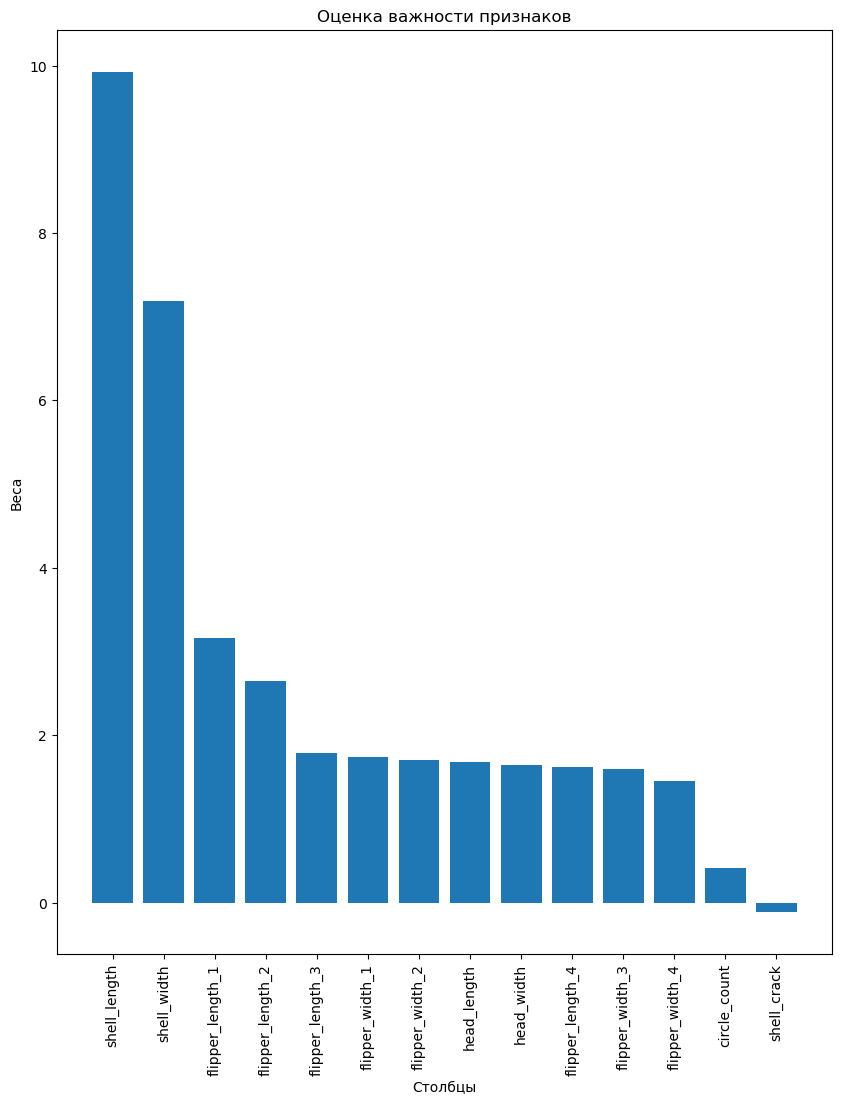

In [67]:
coefs_series = pd.Series(best_coefs, index=X_test.columns)
sorted_coefs = coefs_series.sort_values(ascending=False)

plt.figure(figsize=(10, 12))  
plt.bar(sorted_coefs.index, sorted_coefs)
plt.xticks(rotation=90)
plt.xlabel('Столбцы') 
plt.ylabel('Веса')
plt.title('Оценка важности признаков')
plt.show()

Наиболее важными стали признаки `shell_length`, `shell_width`, я согласна с таким результатом, так как размер панциря напрямую говорит о габаритах черепахи - чем больше размер панциря, тем больше вес черепахи

## Функция для прогнозирования веса черепахи

Напишем функцию для предсказания массы черепахи

In [68]:
train_mean = np.mean(X_train, axis=0)
train_std = np.std(X_train, axis=0)

def weight_pred(shell_length, shell_width, head_length, head_width, 
                flipper_length_1, flipper_width_1, flipper_length_2,
                flipper_width_2, flipper_length_3, flipper_width_3,
                flipper_length_4, flipper_width_4, circle_count, shell_crack):
    feature = np.array([shell_length, shell_width, head_length, head_width, 
                        flipper_length_1, flipper_width_1, flipper_length_2,
                        flipper_width_2, flipper_length_3, flipper_width_3,
                        flipper_length_4, flipper_width_4, circle_count, shell_crack])

    std_feature = (feature - train_mean) / train_std
    res = np.sum(std_feature * best_coefs) + best_int
    return res

Теперь проверим работу функции



In [69]:
for i in range(5):
    pred = X_test.iloc[i]
    true_val = y_test.iloc[i]
    pred_val = weight_pred(*pred)
    print(f"Объект {i}: Реально={true_val:.2f}, Предсказано={pred_val:.2f}, Ошибка={abs(true_val-pred_val):.2f}")

Объект 0: Реально=53.89, Предсказано=46.52, Ошибка=7.38
Объект 1: Реально=66.08, Предсказано=65.11, Ошибка=0.97
Объект 2: Реально=84.51, Предсказано=89.16, Ошибка=4.65
Объект 3: Реально=55.47, Предсказано=48.30, Ошибка=7.17
Объект 4: Реально=128.13, Предсказано=125.68, Ошибка=2.45


Модель практически верно предсказала вес, она подходит для работы

## Общие выводы и рекомендации по дальнейшей работе

Выводы по проделанной работе:

- В ходе работы были изучены модели: базовая модель, модель LinearRegression, модель Lasso (L1-регуляризация), модель Ridge (L2-регуляризация), модель SGDRegressor
- В результате наиболее качетсвенной оказалась модель LinearRegression, которая была обучена на стандартизорованных данных (на валидационной выборке метрики: MSE = 25.54, RMSE = 5.05, MAE = 3.86, MAPE = 0.04, R2 = 0.98)
- Наиболее важными признаками для модели оказались shell_length, shell_width

Рекомендации:

- Для дальнейшего использования рекомендуется модель LinearRegression, так как она подходит род требования заказчика (MAE < 5 и R2 > 0,97), но для дальнейшего расширения на другие виды черепах с данной моделью могут возникнуть трудности, так как она не рассчитана на большие массивы данных, это может сильно замедлить ее работу


In [70]:
!pip install session_info


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [71]:
import session_info
session_info.show()

C:\Users\OC\anaconda3\Lib\site-packages\session_info\main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)
